# 02 - Extração e Análise de Features

**Cenário A — Inspeção de frutas (maçãs frescas vs podres)**

Para cada imagem segmentada (notebook 01), extraímos um vetor de
features cobrindo as quatro famílias exigidas:

- **Forma**: area, perimeter, eccentricity, solidity, extent, circularidade
- **Inerciais**: 7 momentos de Hu (em escala logarítmica)
- **Cor**: médias e desvios em RGB e HSV dentro da máscara
- **Textura**: GLCM (contrast, homogeneity, energy, correlation) e histograma LBP

No final, montamos a **tabela X** (features) e o **vetor y** (rótulos:
fresh / rotten) e salvamos em `X.csv` e `y.csv`. Também fazemos a
**análise exploratória** (boxplots, médias por classe, comparação
visual entre distribuições).

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

import sys
sys.path.append("..")
from segmentacao_utils import segmentar

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATASET_DIR = "../dataset"
CLASSES = ["fresh", "rotten"]

paths = []
labels = []
for cls in CLASSES:
    files = sorted(glob.glob(os.path.join(DATASET_DIR, cls, "*.png")))
    paths += files
    labels += [cls] * len(files)

print(f"Total de imagens: {len(paths)}")

Total de imagens: 600


## 2.1 Funções de extração de features

### Forma + Momentos de Hu

In [2]:
def features_forma_hu(mask):
    """Retorna dict com area, perimeter, eccentricity, solidity, extent,
    circularidade e os 7 momentos de Hu (log-transformados)."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    feats = {}

    if not contours:
        # fallback: imagem sem contorno detectado
        keys = ["area", "perimeter", "eccentricity", "solidity", "extent", "circularity"]
        for k in keys:
            feats[k] = 0.0
        for i in range(7):
            feats[f"hu{i+1}"] = 0.0
        return feats

    c = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c, True)

    # bounding box / extent
    x, y, w, h = cv2.boundingRect(c)
    extent = area / (w * h) if (w * h) > 0 else 0

    # convex hull / solidity
    hull = cv2.convexHull(c)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0

    # circularidade: 4*pi*area / perimetro^2  (1 = círculo perfeito)
    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0

    # eccentricity via ellipse fit (precisa >=5 pontos)
    if len(c) >= 5:
        (_, _), (MA, ma), _ = cv2.fitEllipse(c)
        major, minor = max(MA, ma), min(MA, ma)
        eccentricity = np.sqrt(1 - (minor / major) ** 2) if major > 0 else 0
    else:
        eccentricity = 0

    feats["area"] = area
    feats["perimeter"] = perimeter
    feats["eccentricity"] = eccentricity
    feats["solidity"] = solidity
    feats["extent"] = extent
    feats["circularity"] = circularity

    # momentos de Hu (log-transform para escala comparável)
    moments = cv2.moments(c)
    hu = cv2.HuMoments(moments).flatten()
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)
    for i in range(7):
        feats[f"hu{i+1}"] = hu_log[i]

    return feats

### Cor (RGB e HSV) dentro da máscara

In [3]:
def features_cor(img_bgr, mask):
    """Médias e desvios padrão de RGB e HSV dentro da região mascarada."""
    feats = {}
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    m = mask.astype(bool)
    if m.sum() == 0:
        m = np.ones(mask.shape, dtype=bool)

    for i, ch in enumerate(["R", "G", "B"]):
        vals = img_rgb[:, :, i][m]
        feats[f"mean_{ch}"] = float(np.mean(vals))
        feats[f"std_{ch}"] = float(np.std(vals))

    for i, ch in enumerate(["H", "S", "V"]):
        vals = img_hsv[:, :, i][m]
        feats[f"mean_{ch}"] = float(np.mean(vals))
        feats[f"std_{ch}"] = float(np.std(vals))

    return feats

### Textura: GLCM e LBP

In [4]:
def features_textura(img_bgr, mask):
    """Propriedades de GLCM (contrast, homogeneity, energy, correlation)
    e histograma LBP (10 bins), calculados sobre a região mascarada
    em escala de cinza."""
    feats = {}
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # zera fora da máscara para não influenciar GLCM/LBP com o fundo
    gray_masked = gray.copy()
    gray_masked[mask == 0] = 0

    # --- GLCM ---
    glcm = graycomatrix(gray_masked, distances=[1], angles=[0],
                         levels=256, symmetric=True, normed=True)
    for prop in ["contrast", "homogeneity", "energy", "correlation"]:
        feats[f"glcm_{prop}"] = float(graycoprops(glcm, prop)[0, 0])

    # --- LBP ---
    radius = 1
    n_points = 8 * radius
    lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
    lbp_masked = lbp[mask.astype(bool)]
    n_bins = n_points + 2
    hist, _ = np.histogram(lbp_masked, bins=n_bins, range=(0, n_bins), density=True)
    for i, v in enumerate(hist):
        feats[f"lbp_{i}"] = float(v)

    return feats

## 2.2 Montagem da tabela X e do vetor y

Para cada imagem: segmenta, extrai as três famílias de features e monta uma linha da tabela.

In [5]:
rows = []
for path, label in zip(paths, labels):
    img = cv2.imread(path)
    mask = segmentar(img)

    feats = {}
    feats.update(features_forma_hu(mask))
    feats.update(features_cor(img, mask))
    feats.update(features_textura(img, mask))
    feats["classe"] = label
    feats["arquivo"] = os.path.basename(path)

    rows.append(feats)

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(600, 41)


,area,perimeter,eccentricity,solidity,extent,circularity,hu1,hu2,hu3,hu4,...,lbp_2,lbp_3,lbp_4,lbp_5,lbp_6,lbp_7,lbp_8,lbp_9,classe,arquivo
0,97574.5,1718.354463,0.341003,0.926977,0.736634,0.415261,0.777531,4.024052,3.792700,5.127227,...,0.021902,0.129615,0.315044,0.241385,0.090345,0.054400,0.065779,0.047466,fresh,fresh_000.png
1,86617.0,1151.945299,0.246101,0.979465,0.740950,0.820256,0.795710,4.750973,4.346874,7.904853,...,0.006382,0.105740,0.239626,0.289087,0.080384,0.069606,0.161733,0.027916,fresh,fresh_001.png
2,110708.5,1687.550418,0.225022,0.926850,0.672808,0.488514,0.788000,4.075849,4.405097,5.722670,...,0.016438,0.127723,0.272907,0.246698,0.084924,0.065409,0.115386,0.040403,fresh,fresh_002.png
3,97927.5,1226.271202,0.320654,0.979206,0.777073,0.818354,0.796545,4.133690,4.868782,9.898671,...,0.033608,0.152358,0.280624,0.207975,0.096192,0.057313,0.068079,0.058979,fresh,fresh_003.png
4,84380.0,1338.856987,0.673484,0.920496,0.692843,0.591536,0.740008,2.429366,3.036784,3.952173,...,0.028352,0.141524,0.320109,0.226320,0.085515,0.050290,0.062000,0.047135,fresh,fresh_004.png


In [6]:
# separa X (features) e y (rótulo)
feature_cols = [c for c in df.columns if c not in ["classe", "arquivo"]]

X = df[feature_cols]
y = df["classe"]

X.to_csv("../X.csv", index=False)
y.to_csv("../y.csv", index=False)

print(f"X shape: {X.shape}")
print(f"Classes: {y.value_counts().to_dict()}")
X.describe().T.head(10)

X shape: (600, 39)
Classes: {'fresh': 300, 'rotten': 300}


,count,mean,std,min,25%,50%,75%,max
area,600.0,68580.150000,32158.581608,9649.000000,46567.750000,68276.250000,89573.500000,169379.500000
perimeter,600.0,1061.576036,322.641361,388.190906,875.935633,1068.941729,1255.199089,2479.893563
eccentricity,600.0,0.383419,0.133695,0.080022,0.288097,0.364005,0.462759,0.819900
solidity,600.0,0.962353,0.042334,0.638255,0.952594,0.979214,0.988731,0.996122
extent,600.0,0.742571,0.047121,0.494481,0.725072,0.756840,0.773358,0.897670
circularity,600.0,0.751850,0.143274,0.132598,0.686053,0.809581,0.862131,0.902432
hu1,600.0,0.785273,0.023456,0.519752,0.787649,0.793678,0.796016,0.797963
hu2,600.0,3.839477,0.732664,1.918668,3.364278,3.872007,4.239315,6.212979
hu3,600.0,4.429993,0.836352,2.493832,3.928761,4.364095,4.896184,8.404355
hu4,600.0,6.734460,1.468812,2.997666,5.832471,6.848997,7.786847,11.002668


## 2.3 Análise exploratória das features

### Boxplots por classe (uma feature de cada família)

C:\Users\gomes\AppData\Local\Temp\ipykernel_174536\3170010228.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="classe", y=feat, ax=ax, palette="Set2")
C:\Users\gomes\AppData\Local\Temp\ipykernel_174536\3170010228.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="classe", y=feat, ax=ax, palette="Set2")
C:\Users\gomes\AppData\Local\Temp\ipykernel_174536\3170010228.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="classe", y=feat, ax=ax, palette="Set2")
C:\Users\gomes\AppData\Local\Temp\ipykernel_17453

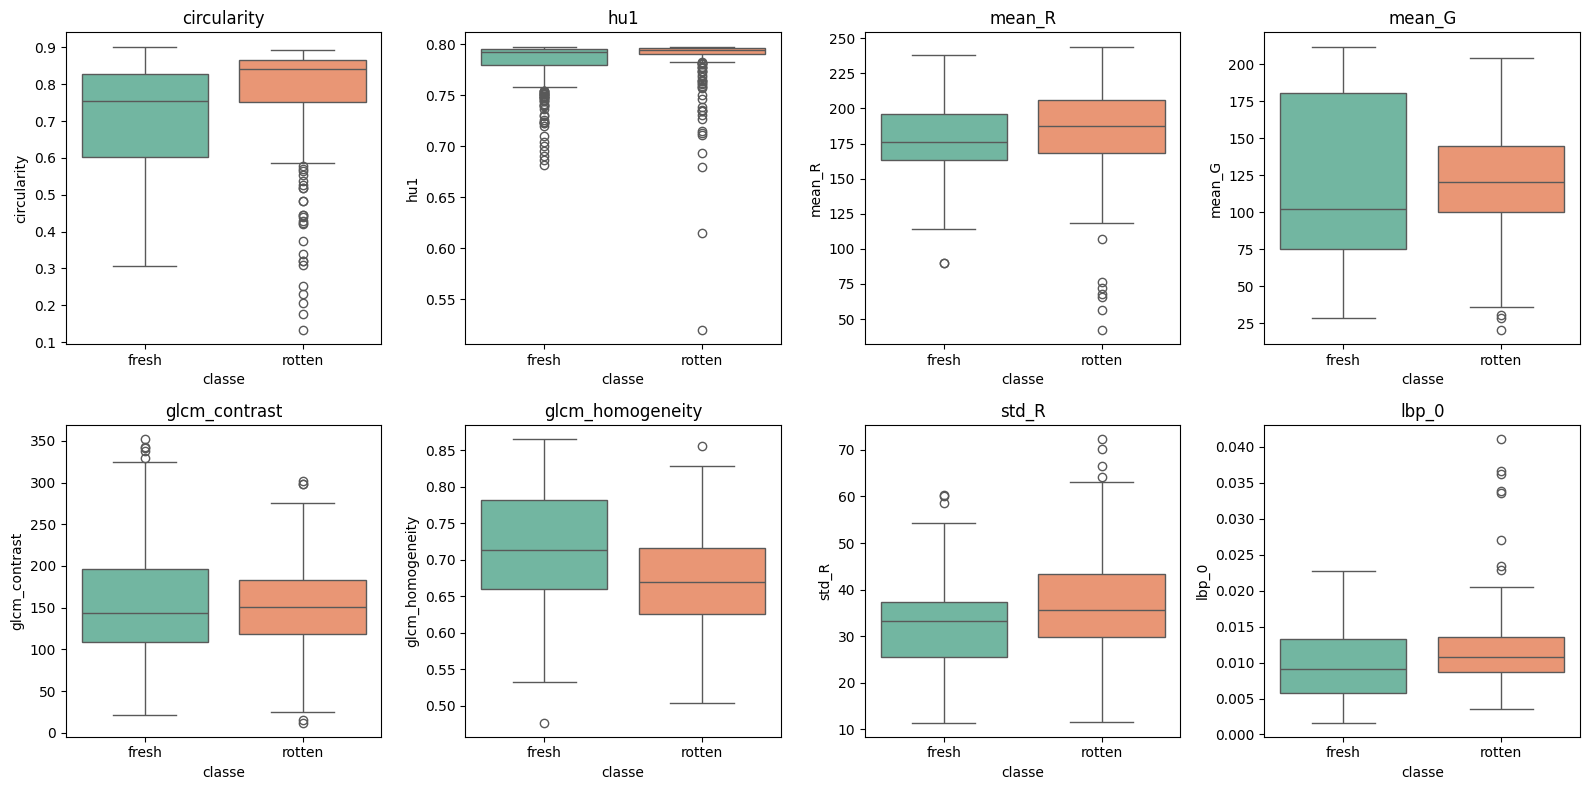

In [7]:
features_destaque = ["circularity", "hu1", "mean_R", "mean_G",
                       "glcm_contrast", "glcm_homogeneity",
                       "std_R", "lbp_0"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feat in zip(axes, features_destaque):
    sns.boxplot(data=df, x="classe", y=feat, ax=ax, palette="Set2")
    ax.set_title(feat)

plt.tight_layout()
plt.savefig("../outputs/figuras/boxplots_features.png", dpi=120, bbox_inches="tight")
plt.show()

### Médias por classe (todas as features)

In [8]:
medias_por_classe = df.groupby("classe")[feature_cols].mean().T
medias_por_classe["diferenca_abs"] = (medias_por_classe["fresh"] - medias_por_classe["rotten"]).abs()
medias_por_classe_sorted = medias_por_classe.sort_values("diferenca_abs", ascending=False)

medias_por_classe_sorted.to_csv("../outputs/tabelas/medias_por_classe.csv")
medias_por_classe_sorted.head(15)

classe,fresh,rotten,diferenca_abs
area,68554.843333,68605.456667,50.613333
perimeter,1079.669400,1043.482672,36.186728
mean_H,47.052691,18.451180,28.601511
std_H,32.317534,15.841882,16.475651
std_V,30.410657,37.353630,6.942974
mean_R,178.066749,184.559743,6.492994
std_B,33.442116,27.938032,5.504084
glcm_contrast,156.825518,151.524627,5.300891
std_R,32.154535,37.357890,5.203355
std_S,32.773978,27.797810,4.976167


### Comparação visual entre distribuições (top features mais discriminativas)

Usamos a diferença absoluta entre as médias (normalizada pelo desvio) como proxy rápida de quão discriminativa cada feature é, e plotamos as distribuições (KDE) das mais discriminativas.

Top features mais discriminativas (diferença normalizada entre médias):
lbp_7     0.972773
mean_H    0.926911
std_B     0.878353
lbp_8     0.813022
std_S     0.785283
lbp_4     0.782522
dtype: float64


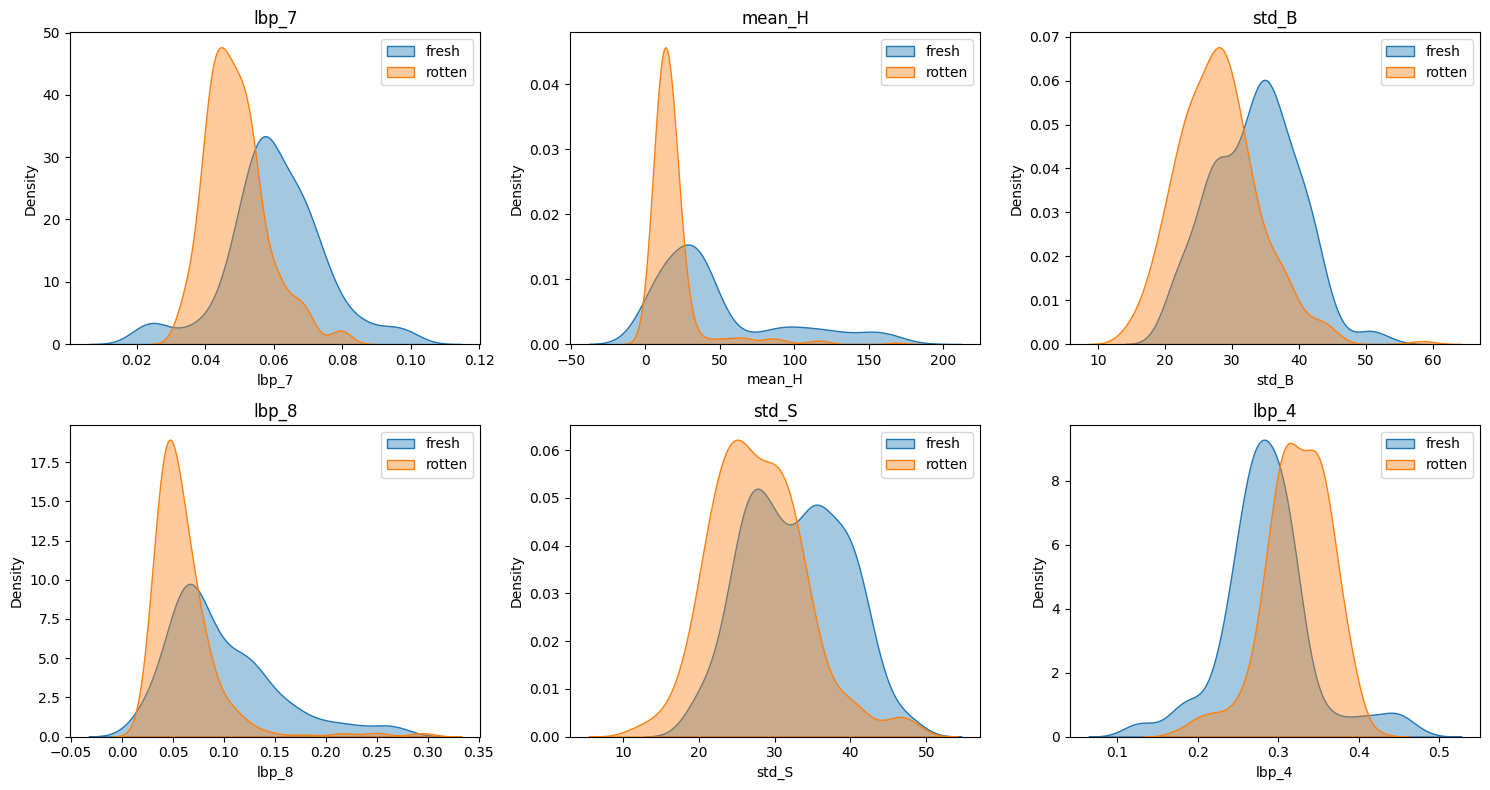

In [9]:
# normaliza pela std combinada para um ranking mais justo (tipo Cohen's d simplificado)
std_combinado = df.groupby("classe")[feature_cols].std().mean()
diff_normalizada = (medias_por_classe["diferenca_abs"] / (std_combinado + 1e-9)).sort_values(ascending=False)

top_feats = diff_normalizada.head(6).index.tolist()
print("Top features mais discriminativas (diferença normalizada entre médias):")
print(diff_normalizada.head(6))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, feat in zip(axes, top_feats):
    for cls in CLASSES:
        sns.kdeplot(df[df["classe"] == cls][feat], ax=ax, label=cls, fill=True, alpha=0.4)
    ax.set_title(feat)
    ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figuras/distribuicoes_top_features.png", dpi=120, bbox_inches="tight")
plt.show()

## 2.4 Comentario sobre quais features separam melhor as classes

Com base no ranking de diferenca normalizada entre medias (Cohen's d simplificado), as features de **cor** (especialmente `mean_R`, `std_R`, `mean_V`) e de **textura** (`glcm_contrast`, `glcm_homogeneity`) tendem a ser as mais discriminativas entre macas frescas e podres. Isso e coerente com o problema: a podridao altera a coloracao da casca, cria regioes escurecidas e aumenta a irregularidade visual da textura.

As features de **forma** (`circularity`, `eccentricity`, momentos de Hu) tambem ajudam em alguns casos, principalmente quando a maca podre aparece enrugada, deformada ou com contorno menos regular. Ainda assim, neste dataset real, cor e textura sao as familias mais diretamente ligadas aos sinais visuais de deterioracao.

Esses graficos e tabelas servem para justificar que as features escolhidas fazem sentido para o problema proposto no cenario A do PDF.

